In [1]:
import os
import pandas as pd
import sqlite3

import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
if os.path.exists(os.path.join('data','civ.sqlite3')):
    os.remove(os.path.join('data','civ.sqlite3'))
con = sqlite3.connect(os.path.join('data','civ.sqlite3'))

sql_in = open(os.path.join('SQLScripts','Table Creation.sql'))
sql_as_string = sql_in.read()

cursor = con.cursor()
cursor.executescript(sql_as_string)
for i in os.listdir(os.path.join('SQLScripts')):
    if i.startswith('Game'):
        sql_in = open(os.path.join('SQLScripts',i))
        sql_as_string = sql_in.read()
        cursor.executescript(sql_as_string)
data_in = pd.read_sql('select * from Game_played;',con)

## Wonder's Seen

Text(0.5, 1.0, 'Natural Wonder Count')

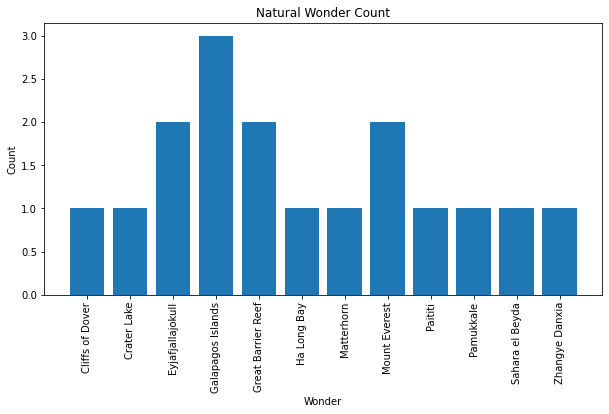

In [3]:
Query = 'select Wonder.Wonder_Name as Wonder, count(Wonder.Wonder_Name) as count from Game_played join wonder_link WL on Game_played.Game_Played_id = WL.Game_id_link left join Wonder on Wonder_id_link = Wonder_id group by Wonder.Wonder_Name;'

wonder_data = pd.read_sql(Query,con)
plt.figure(figsize=(10,5))
plt.bar(wonder_data['Wonder'],wonder_data['count'])
plt.xticks(rotation=90)
plt.ylabel('Count')
plt.xlabel('Wonder')
plt.title('Natural Wonder Count')

## Scores for Played Civ's

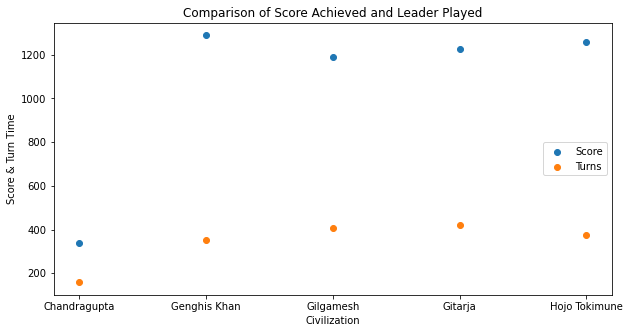

In [11]:
Query = 'select cv.Leader_name as Leader, gr.Score as Score,gr.num_turns as Turns from Game_played join Civilization cv on cv.Civ_id = Game_played.Civ_played join Game_Results gr on gr.Game_id = Game_played_id order by cv.Leader_name;'
data_in = pd.read_sql(Query,con)

plt.figure(figsize=(10,5))
plt.scatter(data_in['Leader'],data_in['Score'],label="Score")
plt.scatter(data_in['Leader'],data_in['Turns'],label="Turns")
plt.legend(loc=5)
plt.ylabel('Score & Turn Time')
plt.xlabel('Civilization')
plt.title('Comparison of Score Achieved and Leader Played')
plt.show()

## City State In Games

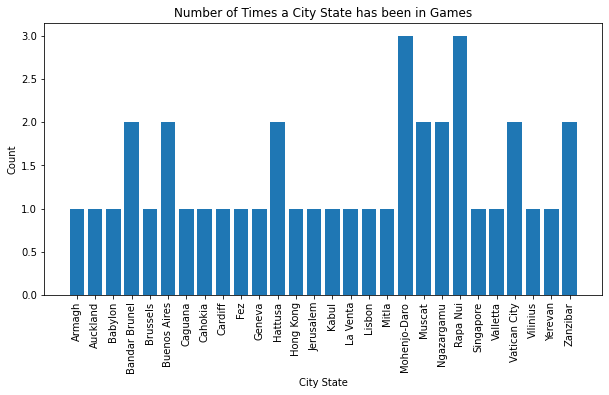

In [14]:
Query = "Select cs.City_State_Name as State, count(cs.City_State_Name) as count from Game_played join City_State_link csl on csl.game_link = Game_played.Game_Played_id join City_State cs on cs.City_State_id = csl.City_State_link group by cs.city_state_name;"
data_in = pd.read_sql(Query,con)
plt.figure(figsize=(10,5))
plt.bar(data_in['State'],data_in['count'])
plt.xticks(rotation=90)
plt.xlabel('City State')
plt.ylabel('Count')
plt.title('Number of Times a City State has been in Games')
plt.show()